In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('house_prices.csv')
data.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [3]:
data.shape

(187531, 21)

In [4]:
data.isnull().sum()

Index                     0
Title                     0
Description            3023
Amount(in rupees)         0
Price (in rupees)     17665
location                  0
Carpet Area           80673
Status                  615
Floor                  7077
Transaction              83
Furnishing             2897
facing                70233
overlooking           81436
Society              109678
Bathroom                828
Balcony               48935
Car Parking          103357
Ownership             65517
Super Area           107685
Dimensions           187531
Plot Area            187531
dtype: int64

In [5]:
missing_sum=data.isnull().sum()
missing_sum=missing_sum[missing_sum>0]
missing_percentage=missing_sum/len(data)*100
missing_values =pd.DataFrame()
missing_values['missing_sum']=missing_sum
missing_values['missing_percentage']=missing_percentage
missing_values=missing_values.sort_values(by='missing_sum', ascending=False)


In [6]:
missing_values

,missing_sum,missing_percentage
Plot Area,187531,100.000000
Dimensions,187531,100.000000
Society,109678,58.485264
Super Area,107685,57.422506
Car Parking,103357,55.114621
overlooking,81436,43.425354
Carpet Area,80673,43.018488
facing,70233,37.451408
Ownership,65517,34.936624
Balcony,48935,26.094352


In [7]:
data = data.drop(columns=['Dimensions', 'Plot Area'])

In [8]:
data['Society'].value_counts()

Society
Hamdam Apartment           1648
Malibu Town                1158
Shree Vardhman Victoria    1154
DLF Skycourt               1153
Nebula Tower                982
                           ... 
Kumar Princeville             1
Nyati Equatorial              1
Sentosa Serene                1
Shubhankar Durvaa             1
Dreams Estate                 1
Name: count, Length: 10376, dtype: int64

In [9]:
data=data.drop(columns=['Society'])

In [10]:
data['Super Area'].value_counts()

Super Area
1100 sqft    2599
1332 sqft    2111
1500 sqft    2018
500 sqft     1665
1000 sqft    1352
             ... 
1992 sqft       1
800 sqm         1
2074 sqft       1
2432 sqft       1
707 sqft        1
Name: count, Length: 2976, dtype: int64

In [11]:
import re

def clean_area(x):
    if pd.isna(x):
        return np.nan
    x = str(x).lower()
    
    # Lấy ra phần số trong chuỗi
    match = re.match(r'([0-9.]+)\s*(.*)', x)
    if match:
        val = float(match.group(1))
        unit = match.group(2).strip()
        
        # Quy đổi đơn vị về cùng sqft để model học chuẩn hơn
        if 'sqm' in unit or 'sq.m.' in unit:
            return val * 10.7639
        elif 'sqyrd' in unit:
            return val * 9.0
        
        return val # Mặc định là sqft
    return np.nan

data['Super Area'] = data['Super Area'].apply(clean_area)
data['Super Area'].head()

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Super Area, dtype: float64

In [12]:
data['Super Area'].value_counts()

Super Area
1100.00    2599
1332.00    2114
1500.00    2018
500.00     1665
1000.00    1352
           ... 
2074.00       1
8611.12       1
1992.00       1
4476.00       1
2767.00       1
Name: count, Length: 2778, dtype: int64

In [13]:
data['Carpet Area'] = data['Carpet Area'].apply(clean_area)
condition = data['Super Area'].isna() & data['Carpet Area'].notna()

data['Super Area'].fillna(data['Super Area'].median(), inplace=True)
data['Super Area'].isnull().sum()

C:\Users\Admin\AppData\Local\Temp\ipykernel_19356\2407255296.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Super Area'].fillna(data['Super Area'].median(), inplace=True)


np.int64(0)

In [14]:
data['Car Parking'].value_counts()

Car Parking
1 Covered      38754
1 Covered,     16991
2 Covered      10691
1 Open          7873
2 Covered,      3978
               ...  
206 Covered        1
205 Covered        1
11 Covered,        1
403 Covered        1
702 Open           1
Name: count, Length: 229, dtype: int64

In [15]:
def clean_parking(x):
    if pd.isna(x):
        return 0  # Coi như không có chỗ để xe nếu bị thiếu (hoặc bạn có thể dùng np.nan tuỳ ý)
    
    x = str(x).lower()
    # Tìm tất cả các con số trong chuỗi (ví dụ: '1 covered, 2 open' -> ['1', '2'])
    numbers = re.findall(r'\d+', x)
    
    if numbers:
        # Cộng tổng tất cả các chỗ để xe lại
        return sum(int(n) for n in numbers)
    return 0

data['Car Parking'] = data['Car Parking'].apply(clean_parking)
data['Car Parking'].value_counts()

Car Parking
0      103357
1       63618
2       17258
10        871
3         585
        ...  
125         1
304         1
207         1
206         1
104         1
Name: count, Length: 157, dtype: int64

In [16]:
data['overlooking']

0                            NaN
1                    Garden/Park
2                    Garden/Park
3                            NaN
4         Garden/Park, Main Road
                   ...          
187526               Garden/Park
187527    Garden/Park, Main Road
187528    Garden/Park, Main Road
187529                 Main Road
187530         Garden/Park, Pool
Name: overlooking, Length: 187531, dtype: object

In [17]:
# Xử lý cột 'overlooking' (View/Tầm nhìn của căn nhà)

# Điền NaN bằng chuỗi rỗng để dễ xử lý text
data['overlooking'] = data['overlooking'].fillna('')

# Tạo các cột nhị phân (0 hoặc 1) cho từng loại view chính
data['view_Main_Road'] = data['overlooking'].str.contains('Main Road', case=False).astype(int)
data['view_Garden_Park'] = data['overlooking'].str.contains('Garden/Park', case=False).astype(int)
data['view_Pool'] = data['overlooking'].str.contains('Pool', case=False).astype(int)

# Xóa cột 'overlooking' gốc đi vì đã tách xong
data = data.drop(columns=['overlooking'])

data[['view_Main_Road', 'view_Garden_Park', 'view_Pool']].head()

,view_Main_Road,view_Garden_Park,view_Pool
0,0,0,0
1,0,1,0
2,0,1,0
3,0,0,0
4,1,1,0


In [18]:
condition2 = data['Carpet Area'].isna() & data['Super Area'].notna()
data.loc[condition2, 'Carpet Area'] = data.loc[condition2, 'Super Area'] / 1.25
data['Carpet Area'] = data['Carpet Area'].fillna(data['Carpet Area'].median())
data['Carpet Area'].isnull().sum()


np.int64(0)

In [19]:
data['facing'].value_counts()

facing
East            54741
North - East    24220
North           16533
West             8574
South            4694
North - West     3843
South - East     2622
South -West      2071
Name: count, dtype: int64

In [20]:
# Xử lý cột 'facing'

# Điền NaN bằng chuỗi rỗng để dễ xử lý text
data['facing'] = data['facing'].fillna('')

# Tạo các cột nhị phân (0 hoặc 1) cho từng loại view chính
data['East'] = data['facing'].str.contains('East', case=False).astype(int)
data['North'] = data['facing'].str.contains('North', case=False).astype(int)
data['West'] = data['facing'].str.contains('West', case=False).astype(int)
data['South'] = data['facing'].str.contains('South', case=False).astype(int)

# Xóa cột 'overlooking' gốc đi vì đã tách xong
data = data.drop(columns=['facing'])

data[['East', 'North', 'West', 'South']].head()

,East,North,West,South
0,0,0,0,0
1,1,0,0,0
2,1,0,0,0
3,0,0,0,0
4,0,0,1,0


In [21]:
data['Ownership'].value_counts()

Ownership
Freehold                112229
Leasehold                 5285
Co-operative Society      3431
Power Of Attorney         1069
Name: count, dtype: int64

In [22]:
data['Ownership'] = data['Ownership'].fillna('')
data['Freehold'] = data['Ownership'].str.contains('Freehold', case=False).astype(int)
data['Leasehold'] = data['Ownership'].str.contains('Leasehold', case=False).astype(int)
data['Co-operative Society'] = data['Ownership'].str.contains('Co-operative Society', case=False).astype(int)
data['Power Of Attorney'] = data['Ownership'].str.contains('Power Of Attorney', case=False).astype(int)
# Xóa cột 'Ownership' gốc đi vì đã tách xong
data = data.drop(columns=['Ownership'])

data[['Freehold', 'Leasehold', 'Co-operative Society', 'Power Of Attorney']].head()

,Freehold,Leasehold,Co-operative Society,Power Of Attorney
0,0,0,0,0
1,1,0,0,0
2,1,0,0,0
3,0,0,0,0
4,0,0,1,0


In [23]:
data['Balcony'].value_counts()

Balcony
2       51809
1       49219
3       27111
4        9420
5         841
6         132
> 10       22
7          14
10         13
8          13
9           2
Name: count, dtype: int64

In [24]:
data['Balcony']=data['Balcony'].replace('> 10', 11)

In [25]:
data['Balcony']=data['Balcony'].fillna(0)

In [26]:
data['Balcony'] = data['Balcony'].astype(int)

In [27]:
data['Transaction'].value_counts()

Transaction
Resale          144172
New Property     42565
Other              709
Rent/Lease           2
Name: count, dtype: int64

In [28]:
data['Transaction']=data['Transaction'].fillna('Other')
data['Resale'] = data['Transaction'].str.contains('Resale', case = False).astype(int)
data['New Property'] = data['Transaction'].str.contains('New Property', case = False).astype(int)
data['Other'] = data['Transaction'].str.contains('Other', case =False).astype(int)
data['Rent/Lease'] = data['Transaction'].str.contains('Rent/Lease', case =False).astype(int)


In [29]:
data=data.drop(columns=['Transaction'])


In [30]:
data[['Resale', 'New Property', 'Other', 'Rent/Lease']].head()

,Resale,New Property,Other,Rent/Lease
0,1,0,0,0
1,1,0,0,0
2,1,0,0,0
3,1,0,0,0
4,1,0,0,0


In [31]:
data['Status'].value_counts()

Status
Ready to Move    186916
Name: count, dtype: int64

In [32]:
data['Status']=data['Status'].fillna('Unready to move')

In [33]:
data['Status'] = data['Status'].fillna('Unready to move')
data['Ready to Move'] = data['Status'].str.contains('Ready to Move', case=False).astype(int)
data['Unready to move'] = data['Status'].str.contains('Unready to move', case=False).astype(int)
data = data.drop(columns=['Status'])
data[['Ready to Move', 'Unready to move']].head()

,Ready to Move,Unready to move
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0


In [34]:
data['Bathroom'].value_counts()
data['Bathroom']=data['Bathroom'].replace('> 10', 11)
data['Bathroom']=data['Bathroom'].fillna(0)
data['Bathroom'] = data['Bathroom'].astype(int)

In [35]:
data['Bathroom'].value_counts()

Bathroom
2     93007
3     55781
1     18654
4     15600
5      3343
0       828
6       209
7        35
11       35
10       14
8        14
9        11
Name: count, dtype: int64

In [36]:
data = data.drop(columns=['Description', 'Title'])
data.head()

,Index,Amount(in rupees),Price (in rupees),location,Carpet Area,Floor,Furnishing,Bathroom,Balcony,Car Parking,...,Freehold,Leasehold,Co-operative Society,Power Of Attorney,Resale,New Property,Other,Rent/Lease,Ready to Move,Unready to move
0,0,42 Lac,6000.0,thane,500.0,10 out of 11,Unfurnished,1,2,0,...,0,0,0,0,1,0,0,0,1,0
1,1,98 Lac,13799.0,thane,473.0,3 out of 22,Semi-Furnished,2,0,1,...,1,0,0,0,1,0,0,0,1,0
2,2,1.40 Cr,17500.0,thane,779.0,10 out of 29,Unfurnished,2,0,1,...,1,0,0,0,1,0,0,0,1,0
3,3,25 Lac,NaN,thane,530.0,1 out of 3,Unfurnished,1,1,0,...,0,0,0,0,1,0,0,0,1,0
4,4,1.60 Cr,18824.0,thane,635.0,20 out of 42,Unfurnished,2,0,1,...,0,0,1,0,1,0,0,0,1,0


In [37]:
data['Floor']

0         10 out of 11
1          3 out of 22
2         10 out of 29
3           1 out of 3
4         20 out of 42
              ...     
187526      2 out of 4
187527      4 out of 6
187528      1 out of 3
187529      2 out of 2
187530     5 out of 13
Name: Floor, Length: 187531, dtype: object

In [38]:
data['Floor']=data['Floor'].fillna('')
data['Floor']=data['Floor'].str.split(' ').str[0]
data['Floor'].value_counts()


Floor
2         33545
1         31522
3         26829
4         17873
5         12677
Ground    12354
           7077
6          6964
7          6722
8          5429
10         5015
12         4382
11         3035
9          2992
15         1638
14         1619
18         1263
16         1179
13         1096
17          989
19          887
32          722
20          348
21          261
Upper       226
23          144
Lower       136
22          103
25           94
24           82
26           63
28           53
30           47
27           39
29           24
33           12
40           12
35           11
31           11
34           11
38            7
50            4
42            4
60            4
37            3
39            3
45            3
63            2
70            2
75            2
46            2
44            2
36            2
59            2
51            2
200           1
Name: count, dtype: int64

In [39]:
# Biến đổi các giá trị chữ thành số tương ứng
data['Floor'] = data['Floor'].replace('Ground', 0)
data['Floor'] = data['Floor'].replace('Lower', -1)
data = data[data['Floor'] != 'Upper']
# Ép các giá trị về kiểu số 
data['Floor'] = pd.to_numeric(data['Floor'])

# Xóa luôn những dòng NaN ở cột Floor (bao gồm cả 7077 dòng missing ban đầu)
data = data.dropna(subset=['Floor'])

# Kiểm tra lại xem Floor đã sạch sẽ hoàn toàn chưa
data['Floor'].value_counts()

Floor
 2.0      33545
 1.0      31522
 3.0      26829
 4.0      17873
 5.0      12677
 0.0      12354
 6.0       6964
 7.0       6722
 8.0       5429
 10.0      5015
 12.0      4382
 11.0      3035
 9.0       2992
 15.0      1638
 14.0      1619
 18.0      1263
 16.0      1179
 13.0      1096
 17.0       989
 19.0       887
 32.0       722
 20.0       348
 21.0       261
 23.0       144
-1.0        136
 22.0       103
 25.0        94
 24.0        82
 26.0        63
 28.0        53
 30.0        47
 27.0        39
 29.0        24
 33.0        12
 40.0        12
 35.0        11
 31.0        11
 34.0        11
 38.0         7
 50.0         4
 42.0         4
 60.0         4
 37.0         3
 39.0         3
 45.0         3
 63.0         2
 70.0         2
 75.0         2
 46.0         2
 44.0         2
 36.0         2
 59.0         2
 51.0         2
 200.0        1
Name: count, dtype: int64

In [40]:
data.isnull().sum()

Index                       0
Amount(in rupees)           0
Price (in rupees)       17405
location                    0
Carpet Area                 0
Floor                       0
Furnishing               2163
Bathroom                    0
Balcony                     0
Car Parking                 0
Super Area                  0
view_Main_Road              0
view_Garden_Park            0
view_Pool                   0
East                        0
North                       0
West                        0
South                       0
Freehold                    0
Leasehold                   0
Co-operative Society        0
Power Of Attorney           0
Resale                      0
New Property                0
Other                       0
Rent/Lease                  0
Ready to Move               0
Unready to move             0
dtype: int64

In [41]:
data['Furnishing'].value_counts()

Furnishing
Semi-Furnished    86722
Unfurnished       71408
Furnished         19935
Name: count, dtype: int64

In [42]:
data = data.dropna(subset=['Furnishing'])
data['Semi-Furnished'] = data['Furnishing'].str.contains('Semi-Furnished', case=False).astype(int)
data['Unfurnished'] = data['Furnishing'].str.contains('Unfurnished', case=False).astype(int)
data['Furnished'] = data['Furnishing'].str.contains('Furnished', case=False).astype(int)

In [43]:
data = data.drop(columns='Furnishing')

In [44]:
data.shape

(178065, 30)

In [45]:
data.isnull().sum()

Index                       0
Amount(in rupees)           0
Price (in rupees)       16615
location                    0
Carpet Area                 0
Floor                       0
Bathroom                    0
Balcony                     0
Car Parking                 0
Super Area                  0
view_Main_Road              0
view_Garden_Park            0
view_Pool                   0
East                        0
North                       0
West                        0
South                       0
Freehold                    0
Leasehold                   0
Co-operative Society        0
Power Of Attorney           0
Resale                      0
New Property                0
Other                       0
Rent/Lease                  0
Ready to Move               0
Unready to move             0
Semi-Furnished              0
Unfurnished                 0
Furnished                   0
dtype: int64

In [46]:
data['Amount(in rupees)'].value_counts()

Amount(in rupees)
Call for Price    8755
85 Lac            5230
65 Lac            4163
60 Lac            3811
70 Lac            3749
                  ... 
3.93 Cr              1
5.53 Cr              1
8.79 Cr              1
5.57 Cr              1
2.1 Lac              1
Name: count, Length: 1521, dtype: int64

In [47]:
data['Price (in rupees)'].isnull().sum()

np.int64(16615)

In [48]:
data

,Index,Amount(in rupees),Price (in rupees),location,Carpet Area,Floor,Bathroom,Balcony,Car Parking,Super Area,...,Power Of Attorney,Resale,New Property,Other,Rent/Lease,Ready to Move,Unready to move,Semi-Furnished,Unfurnished,Furnished
0,0,42 Lac,6000.0,thane,500.0,10.0,1,2,0,1285.0,...,0,1,0,0,0,1,0,0,1,1
1,1,98 Lac,13799.0,thane,473.0,3.0,2,0,1,1285.0,...,0,1,0,0,0,1,0,1,0,1
2,2,1.40 Cr,17500.0,thane,779.0,10.0,2,0,1,1285.0,...,0,1,0,0,0,1,0,0,1,1
3,3,25 Lac,NaN,thane,530.0,1.0,1,1,0,1285.0,...,0,1,0,0,0,1,0,0,1,1
4,4,1.60 Cr,18824.0,thane,635.0,20.0,2,0,1,1285.0,...,0,1,0,0,0,1,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187526,187526,63 Lac,3225.0,zirakpur,1562.4,2.0,3,3,1,1953.0,...,0,0,1,0,0,1,0,1,0,1
187527,187527,55 Lac,3274.0,zirakpur,1344.0,4.0,3,0,1,1680.0,...,0,1,0,0,0,1,0,0,1,1
187528,187528,76 Lac,4343.0,zirakpur,1250.0,1.0,3,2,1,1285.0,...,0,1,0,0,0,1,0,0,0,1
187529,187529,30 Lac,4231.0,zirakpur,567.2,2.0,2,0,0,709.0,...,0,1,0,0,0,1,0,1,0,1


In [49]:
data = data.drop(columns=['Price (in rupees)'])

In [50]:
data['price_unit'] = data['Amount(in rupees)'].str.extract(r'([A-Za-z]+)', expand = False)

In [51]:
data['price_unit'].value_counts()

price_unit
Lac     108380
Cr       60930
Call      8755
Name: count, dtype: int64

In [52]:
data=data[data['price_unit'] != 'Call']

In [53]:
data['Amount(in rupees)'] = data['Amount(in rupees)'].str.split(' ').str[0]

In [54]:
data['Amount(in rupees)'] = pd.to_numeric(data['Amount(in rupees)'])

In [55]:
mask = data['price_unit'].str.lower() == 'lac'
data.loc[mask, 'Amount(in rupees)'] = (
    data.loc[mask, 'Amount(in rupees)'] * 100000 / 83.5
)

In [56]:
mask_cr  = data['price_unit'].str.lower() == 'cr'
data.loc[mask_cr,  'Amount(in rupees)'] = data.loc[mask_cr,  'Amount(in rupees)'] * 10000000 / 83.5

In [57]:
data['Amount(in rupees)']

0          50299.401198
1         117365.269461
2         167664.670659
3          29940.119760
4         191616.766467
              ...      
187526     75449.101796
187527     65868.263473
187528     91017.964072
187529     35928.143713
187530    141317.365269
Name: Amount(in rupees), Length: 169310, dtype: float64

In [58]:
data['Amount(in USD)'] = data['Amount(in rupees)']

In [59]:
data = data.drop(columns=['Amount(in rupees)','price_unit','Index'])

In [60]:
data

,location,Carpet Area,Floor,Bathroom,Balcony,Car Parking,Super Area,view_Main_Road,view_Garden_Park,view_Pool,...,Resale,New Property,Other,Rent/Lease,Ready to Move,Unready to move,Semi-Furnished,Unfurnished,Furnished,Amount(in USD)
0,thane,500.0,10.0,1,2,0,1285.0,0,0,0,...,1,0,0,0,1,0,0,1,1,50299.401198
1,thane,473.0,3.0,2,0,1,1285.0,0,1,0,...,1,0,0,0,1,0,1,0,1,117365.269461
2,thane,779.0,10.0,2,0,1,1285.0,0,1,0,...,1,0,0,0,1,0,0,1,1,167664.670659
3,thane,530.0,1.0,1,1,0,1285.0,0,0,0,...,1,0,0,0,1,0,0,1,1,29940.119760
4,thane,635.0,20.0,2,0,1,1285.0,1,1,0,...,1,0,0,0,1,0,0,1,1,191616.766467
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187526,zirakpur,1562.4,2.0,3,3,1,1953.0,0,1,0,...,0,1,0,0,1,0,1,0,1,75449.101796
187527,zirakpur,1344.0,4.0,3,0,1,1680.0,1,1,0,...,1,0,0,0,1,0,0,1,1,65868.263473
187528,zirakpur,1250.0,1.0,3,2,1,1285.0,1,1,0,...,1,0,0,0,1,0,0,0,1,91017.964072
187529,zirakpur,567.2,2.0,2,0,0,709.0,1,0,0,...,1,0,0,0,1,0,1,0,1,35928.143713


In [61]:
data['location'].value_counts()

location
new-delhi      24880
bangalore      22155
kolkata        20180
gurgaon        18170
ahmedabad      12193
               ...  
palakkad          29
navsari           28
pondicherry       28
nellore           28
madurai           22
Name: count, Length: 81, dtype: int64

In [62]:
data.head()

,location,Carpet Area,Floor,Bathroom,Balcony,Car Parking,Super Area,view_Main_Road,view_Garden_Park,view_Pool,...,Resale,New Property,Other,Rent/Lease,Ready to Move,Unready to move,Semi-Furnished,Unfurnished,Furnished,Amount(in USD)
0,thane,500.0,10.0,1,2,0,1285.0,0,0,0,...,1,0,0,0,1,0,0,1,1,50299.401198
1,thane,473.0,3.0,2,0,1,1285.0,0,1,0,...,1,0,0,0,1,0,1,0,1,117365.269461
2,thane,779.0,10.0,2,0,1,1285.0,0,1,0,...,1,0,0,0,1,0,0,1,1,167664.670659
3,thane,530.0,1.0,1,1,0,1285.0,0,0,0,...,1,0,0,0,1,0,0,1,1,29940.119760
4,thane,635.0,20.0,2,0,1,1285.0,1,1,0,...,1,0,0,0,1,0,0,1,1,191616.766467


In [63]:
# Xử lý cột location bằng One-Hot Encoding
# Gom các thành phố ít xuất hiện (<100 lần) thành 'other'
freq = data['location'].value_counts()
rare_locs = freq[freq < 100].index

data['location_clean'] = data['location'].replace(rare_locs, 'other')

# Mã hóa one-hot
loc_dummies = pd.get_dummies(data['location_clean'], prefix='loc')

# Chuyển True/False thành 1/0 nếu cần (tùy phiên bản pandas mới)
loc_dummies = loc_dummies.astype(int)

# Ghép vào data và xóa cột cũ
data = pd.concat([data, loc_dummies], axis=1)
data = data.drop(columns=['location', 'location_clean'])

data.head()

,Carpet Area,Floor,Bathroom,Balcony,Car Parking,Super Area,view_Main_Road,view_Garden_Park,view_Pool,East,...,loc_thrissur,loc_trichy,loc_trivandrum,loc_udaipur,loc_vadodara,loc_vapi,loc_varanasi,loc_vijayawada,loc_visakhapatnam,loc_zirakpur
0,500.0,10.0,1,2,0,1285.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,473.0,3.0,2,0,1,1285.0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
2,779.0,10.0,2,0,1,1285.0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
3,530.0,1.0,1,1,0,1285.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,635.0,20.0,2,0,1,1285.0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0


Thống kê mô tả cho Amount(in USD):
count    1.693100e+05
mean     1.432678e+05
std      4.824437e+05
min      1.197605e+03
25%      5.724551e+04
50%      9.053892e+04
75%      1.796407e+05
max      1.677006e+08
Name: Amount(in USD), dtype: float64


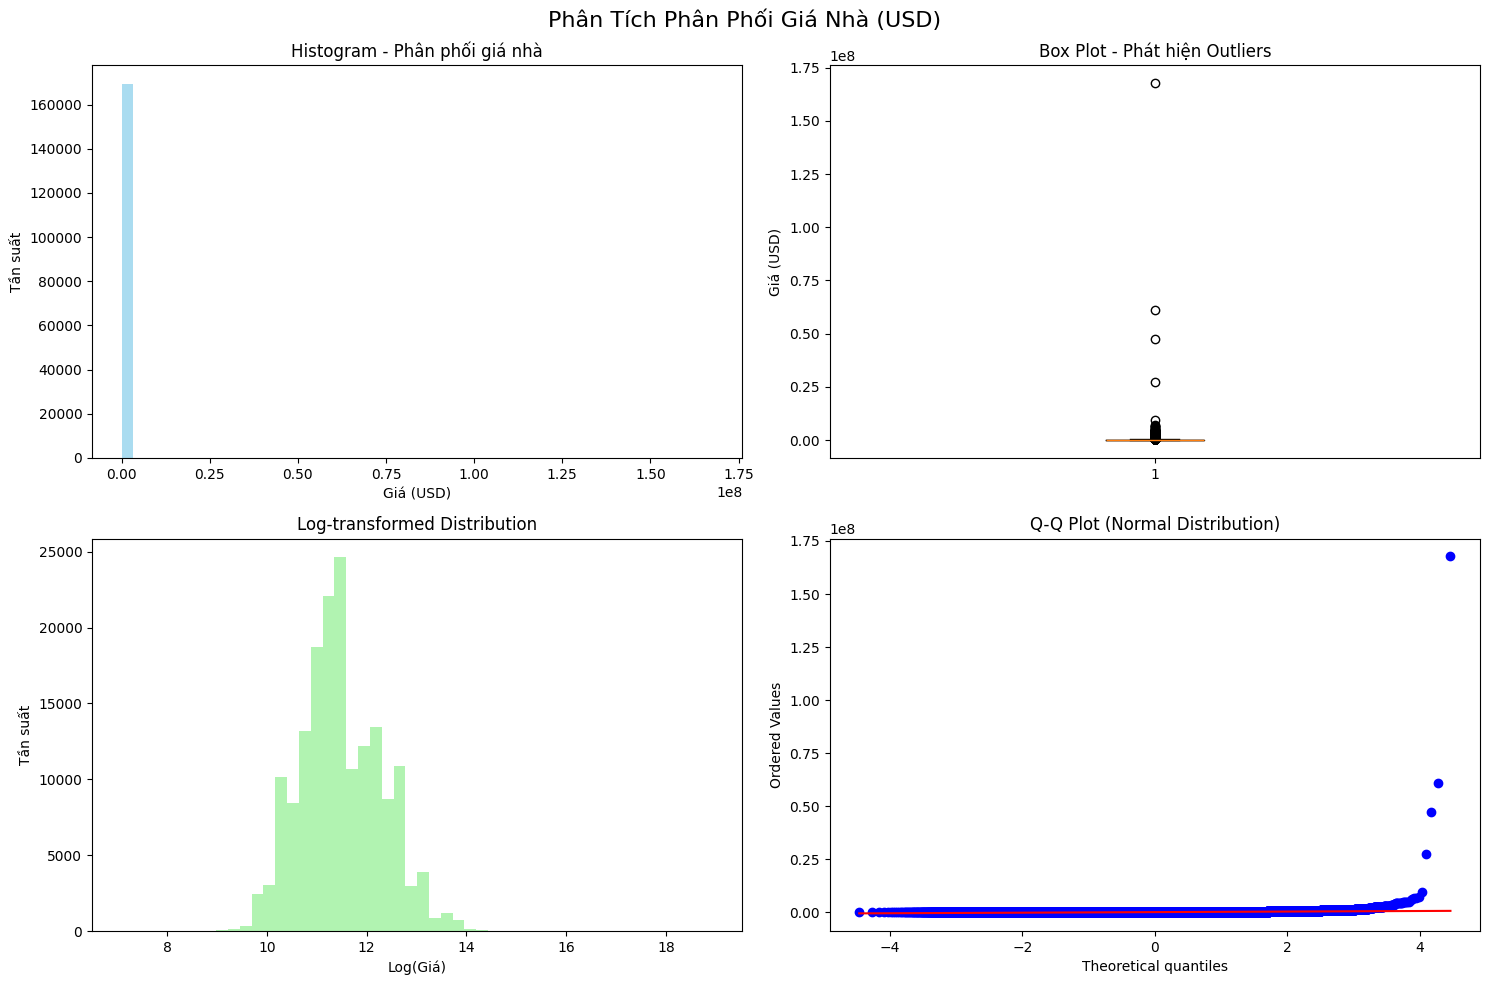

In [64]:
target_col = 'Amount(in USD)'

print(f"Thống kê mô tả cho {target_col}:")
print(data[target_col].describe())

# Vẽ biểu đồ phân phối giá nhà
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Phân Tích Phân Phối Giá Nhà (USD)', fontsize=16)

# Histogram
axes[0,0].hist(data[target_col], bins=50, alpha=0.7, color='skyblue')
axes[0,0].set_title('Histogram - Phân phối giá nhà')
axes[0,0].set_xlabel('Giá (USD)')
axes[0,0].set_ylabel('Tần suất')

# Box plot
axes[0,1].boxplot(data[target_col])
axes[0,1].set_title('Box Plot - Phát hiện Outliers')
axes[0,1].set_ylabel('Giá (USD)')

# Log transformation
axes[1,0].hist(np.log(data[target_col]), bins=50, alpha=0.7, color='lightgreen')
axes[1,0].set_title('Log-transformed Distribution')
axes[1,0].set_xlabel('Log(Giá)')
axes[1,0].set_ylabel('Tần suất')

# QQ plot để kiểm tra tính chuẩn
from scipy import stats
stats.probplot(data[target_col], dist="norm", plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot (Normal Distribution)')

plt.tight_layout()
plt.show()

In [65]:
# Lọc Outliers (giá trị ngoại lai) bằng phương pháp IQR cho cột Giá (Price in USD)
Q1 = data['Amount(in USD)'].quantile(0.25)
Q3 = data['Amount(in USD)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Số dòng trước khi lọc Outliers:", len(data))

# Giữ lại những dòng có giá nằm trong giới hạn an toàn [lower_bound, upper_bound]
data = data[(data['Amount(in USD)'] >= lower_bound) & (data['Amount(in USD)'] <= upper_bound)]

print("Số dòng sau khi lọc Outliers:", len(data))

Số dòng trước khi lọc Outliers: 169310
Số dòng sau khi lọc Outliers: 159599


In [66]:
# EDA - Phân tích các biến numeric: Carpet Area, Floor, Bathroom, Balcony, Super Area
print("=== PHÂN TÍCH EDA CÁC BIẾN NUMERIC CHÍNH ===\n")

# Danh sách các biến numeric cần phân tích
numeric_features = ['Carpet Area', 'Floor', 'Bathroom', 'Balcony', 'Super Area']
target_col = 'Amount(in USD)'

# 1. Thống kê mô tả tổng quan
print("1. THỐNG KÊ MÔ TẢ:")
print(data[numeric_features].describe())

# 2. Kiểm tra giá trị thiếu
print("\n2. GIÁ TRỊ THIẾU:")
missing_info = data[numeric_features].isnull().sum()
missing_pct = (missing_info / len(data) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing_info, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

# 3. Phân tích độ lệch (Skewness)
print("\n3. ĐỘ LỆCH PHÂN PHỐI (SKEWNESS):")
for col in numeric_features:
    skew = data[col].skew()
    interpretation = "Lệch phải" if skew > 1 else "Lệch trái" if skew < -1 else "Gần chuẩn"
    print(f"{col:15s}: {skew:6.2f} ({interpretation})")

=== PHÂN TÍCH EDA CÁC BIẾN NUMERIC CHÍNH ===

1. THỐNG KÊ MÔ TẢ:
         Carpet Area          Floor       Bathroom        Balcony  \
count  159599.000000  159599.000000  159599.000000  159599.000000   
mean     1122.699929       4.185997       2.351813       1.498907   
std      2152.572948       4.057062       0.767822       1.184678   
min         0.800000      -1.000000       0.000000       0.000000   
25%       800.000000       1.000000       2.000000       1.000000   
50%      1008.000000       3.000000       2.000000       1.000000   
75%      1400.000000       5.000000       3.000000       2.000000   
max    709222.000000     200.000000      11.000000      11.000000   

          Super Area  
count  159599.000000  
mean     1304.138681  
std       370.556554  
min         1.000000  
25%      1285.000000  
50%      1285.000000  
75%      1285.000000  
max     13993.070000  

2. GIÁ TRỊ THIẾU:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

3. ĐỘ LỆCH PHÂN PHỐI (SK

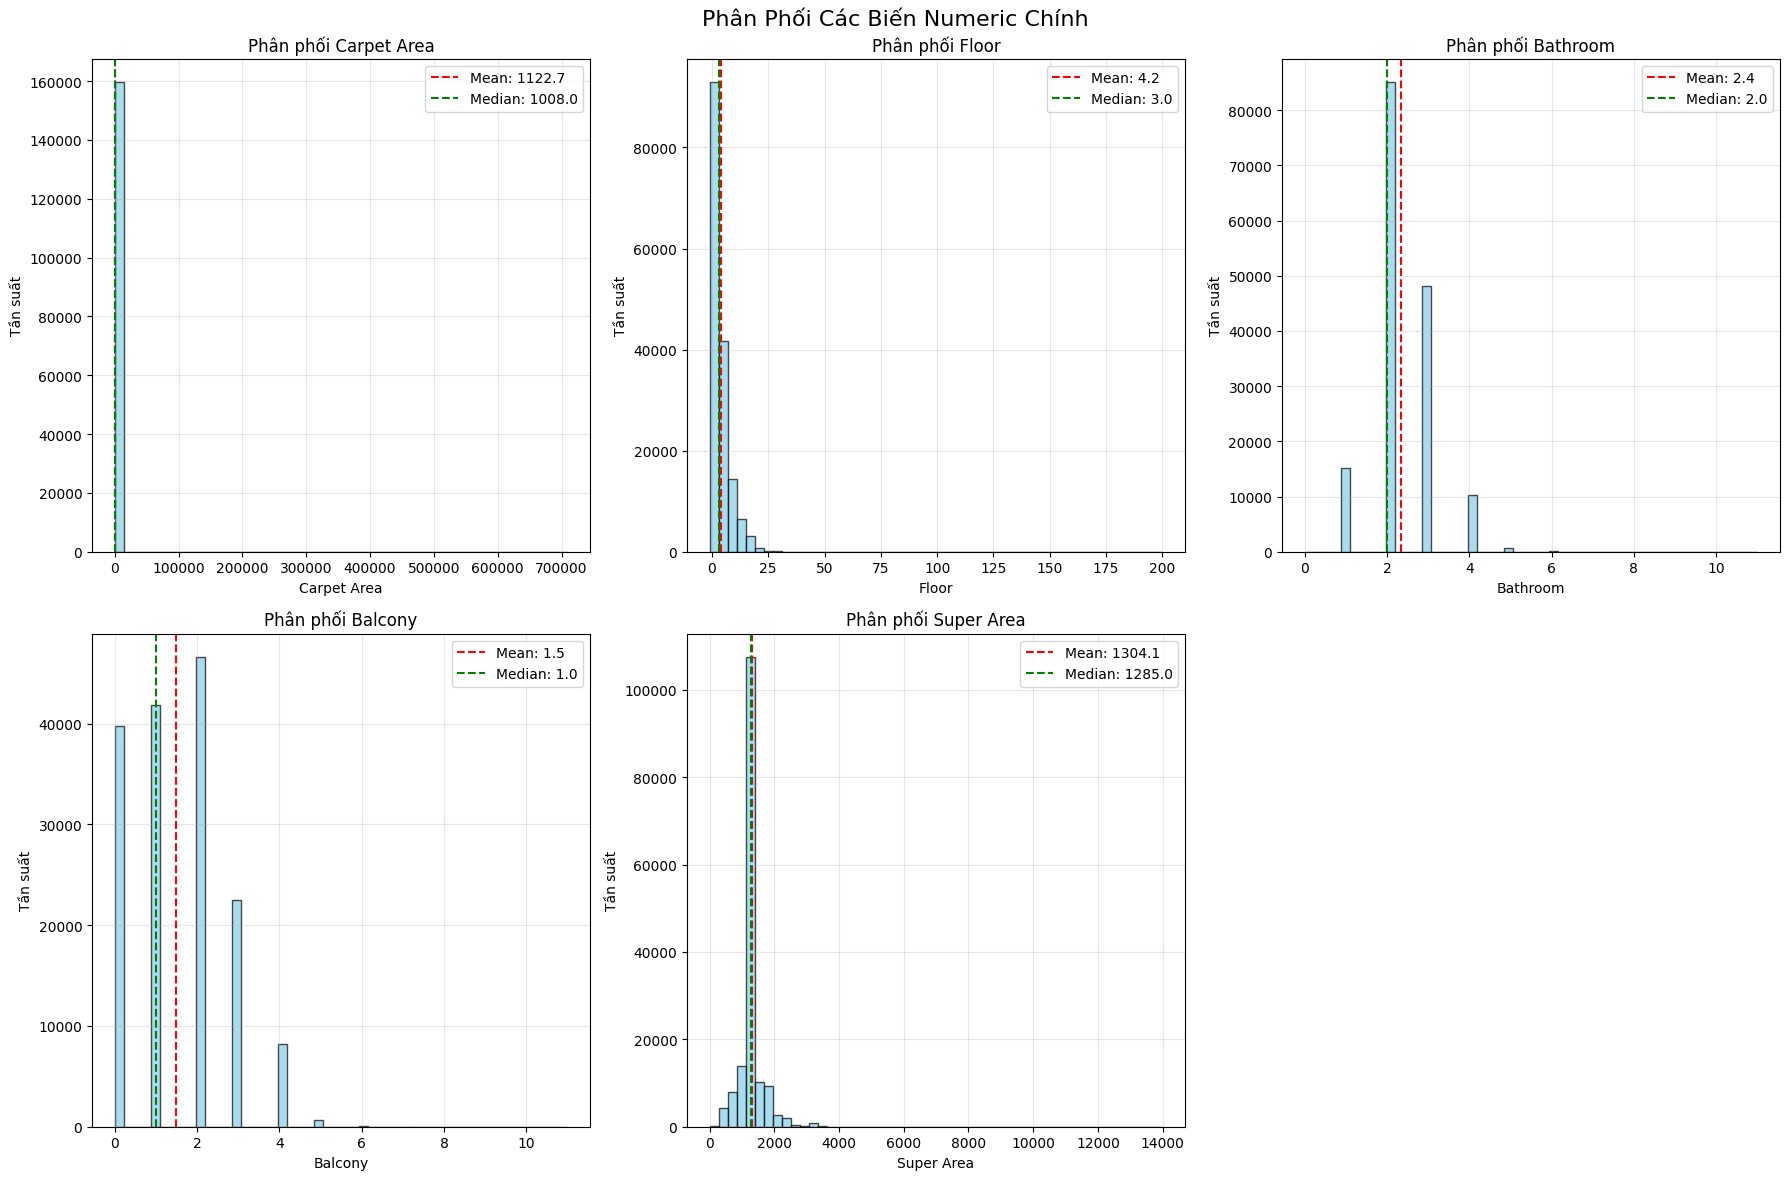

In [67]:
# 4. Biểu đồ phân phối (Histograms)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Phân Phối Các Biến Numeric Chính', fontsize=16)

for i, col in enumerate(numeric_features):
    row = i // 3
    col_idx = i % 3
    
    # Histogram
    axes[row, col_idx].hist(data[col].dropna(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[row, col_idx].set_title(f'Phân phối {col}', fontsize=12)
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel('Tần suất')
    axes[row, col_idx].grid(True, alpha=0.3)
    
    # Thêm thống kê lên biểu đồ
    mean_val = data[col].mean()
    median_val = data[col].median()
    axes[row, col_idx].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
    axes[row, col_idx].axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.1f}')
    axes[row, col_idx].legend()

# Ẩn subplot thừa
axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()

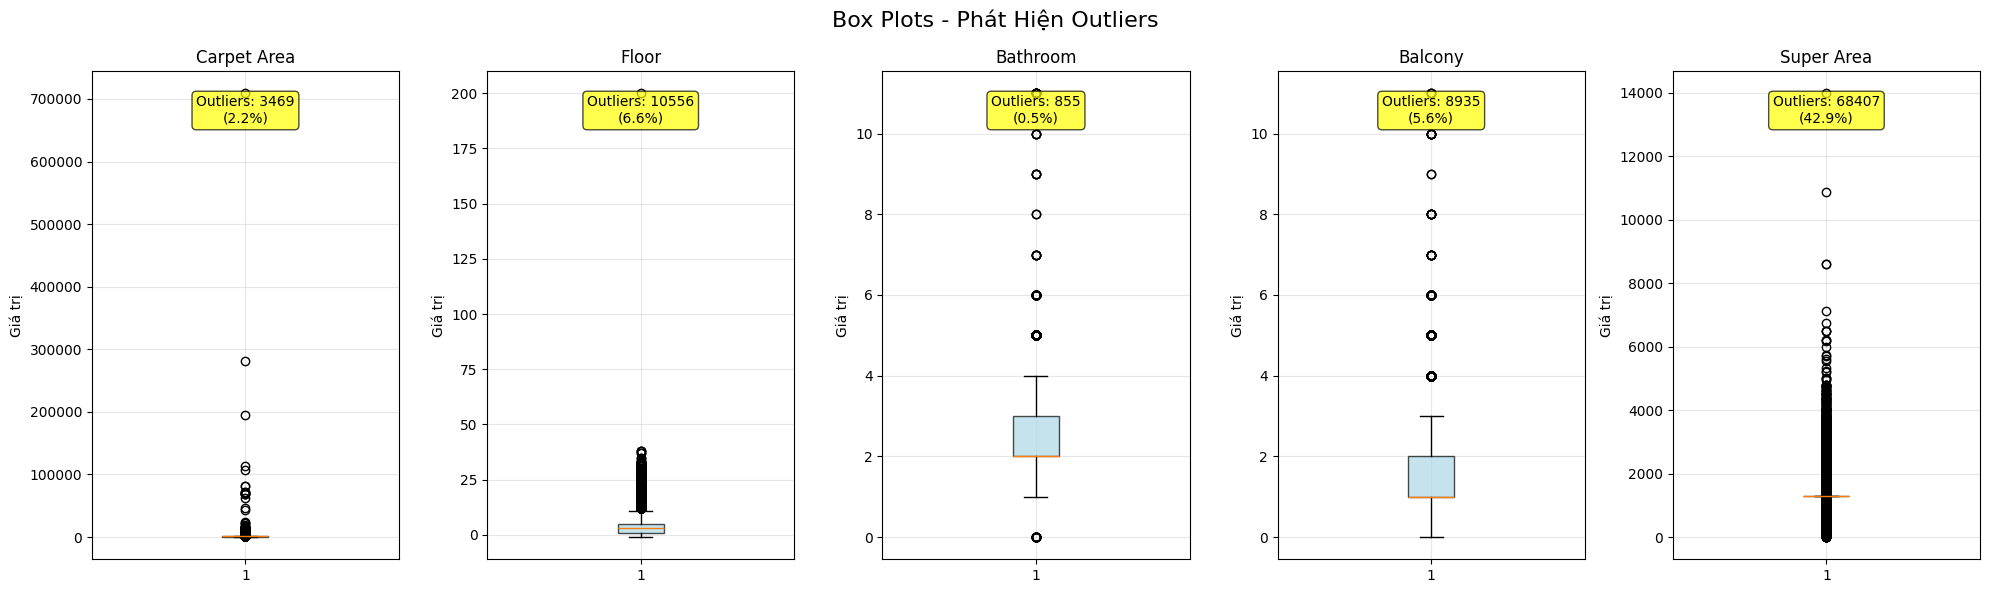

In [68]:
# 5. Box Plots - Phát hiện Outliers
fig, axes = plt.subplots(1, 5, figsize=(20, 6))
fig.suptitle('Box Plots - Phát Hiện Outliers', fontsize=16)

for i, col in enumerate(numeric_features):
    box_data = data[col].dropna()
    
    # Vẽ boxplot
    bp = axes[i].boxplot(box_data, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][0].set_alpha(0.7)
    
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_ylabel('Giá trị')
    axes[i].grid(True, alpha=0.3)
    
    # Tính và hiển thị số outliers
    Q1 = box_data.quantile(0.25)
    Q3 = box_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = box_data[(box_data < lower_bound) | (box_data > upper_bound)]
    outlier_count = len(outliers)
    outlier_pct = (outlier_count / len(box_data) * 100)
    
    axes[i].text(0.5, 0.95, f'Outliers: {outlier_count}\n({outlier_pct:.1f}%)', 
                transform=axes[i].transAxes, ha='center', va='top', 
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

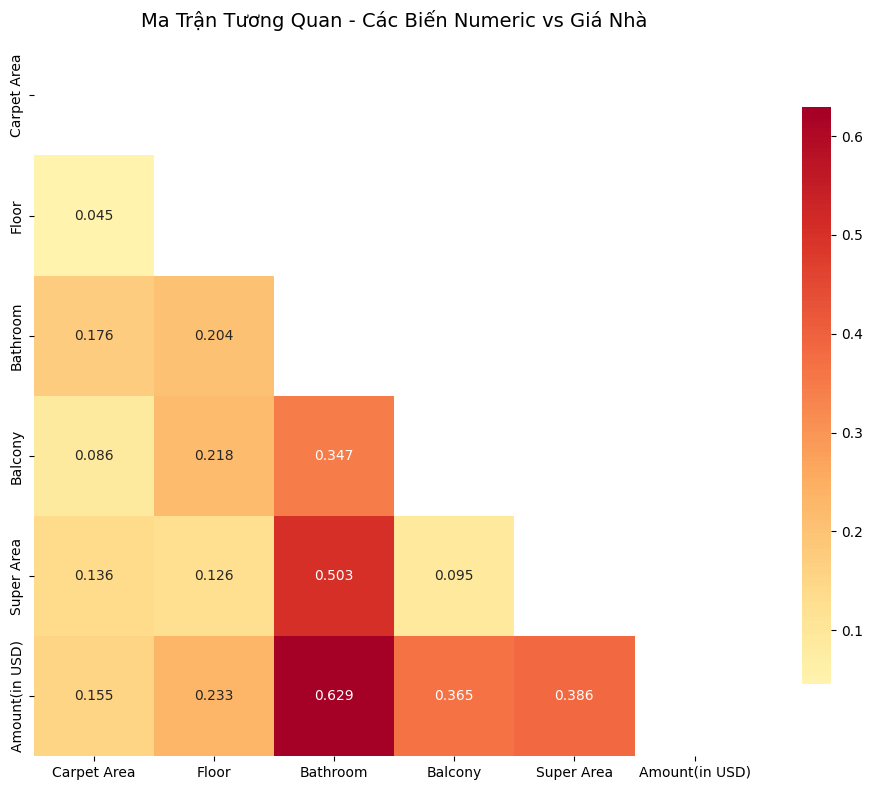


4. TƯƠNG QUAN VỚI GIÁ NHÀ:
Bathroom       : 0.629 (Tương quan Mạnh)
Super Area     : 0.386 (Tương quan Vừa)
Balcony        : 0.365 (Tương quan Vừa)
Floor          : 0.233 (Tương quan Yếu)
Carpet Area    : 0.155 (Tương quan Yếu)


In [71]:
import seaborn as sns 
# 6. Ma trận tương quan với Target và giữa các biến
correlation_data = data[numeric_features + [target_col]]
corr_matrix = correlation_data.corr()

# Vẽ heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Chỉ hiển thị nửa dưới
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdYlBu_r', center=0, 
            square=True, fmt='.3f', cbar_kws={"shrink": .8})
plt.title('Ma Trận Tương Quan - Các Biến Numeric vs Giá Nhà', fontsize=14)
plt.tight_layout()
plt.show()

# In ra tương quan với target
print("\n4. TƯƠNG QUAN VỚI GIÁ NHÀ:")
target_corr = corr_matrix[target_col].drop(target_col).abs().sort_values(ascending=False)
for feature, corr in target_corr.items():
    strength = "Mạnh" if corr > 0.5 else "Vừa" if corr > 0.3 else "Yếu"
    print(f"{feature:15s}: {corr:.3f} (Tương quan {strength})")

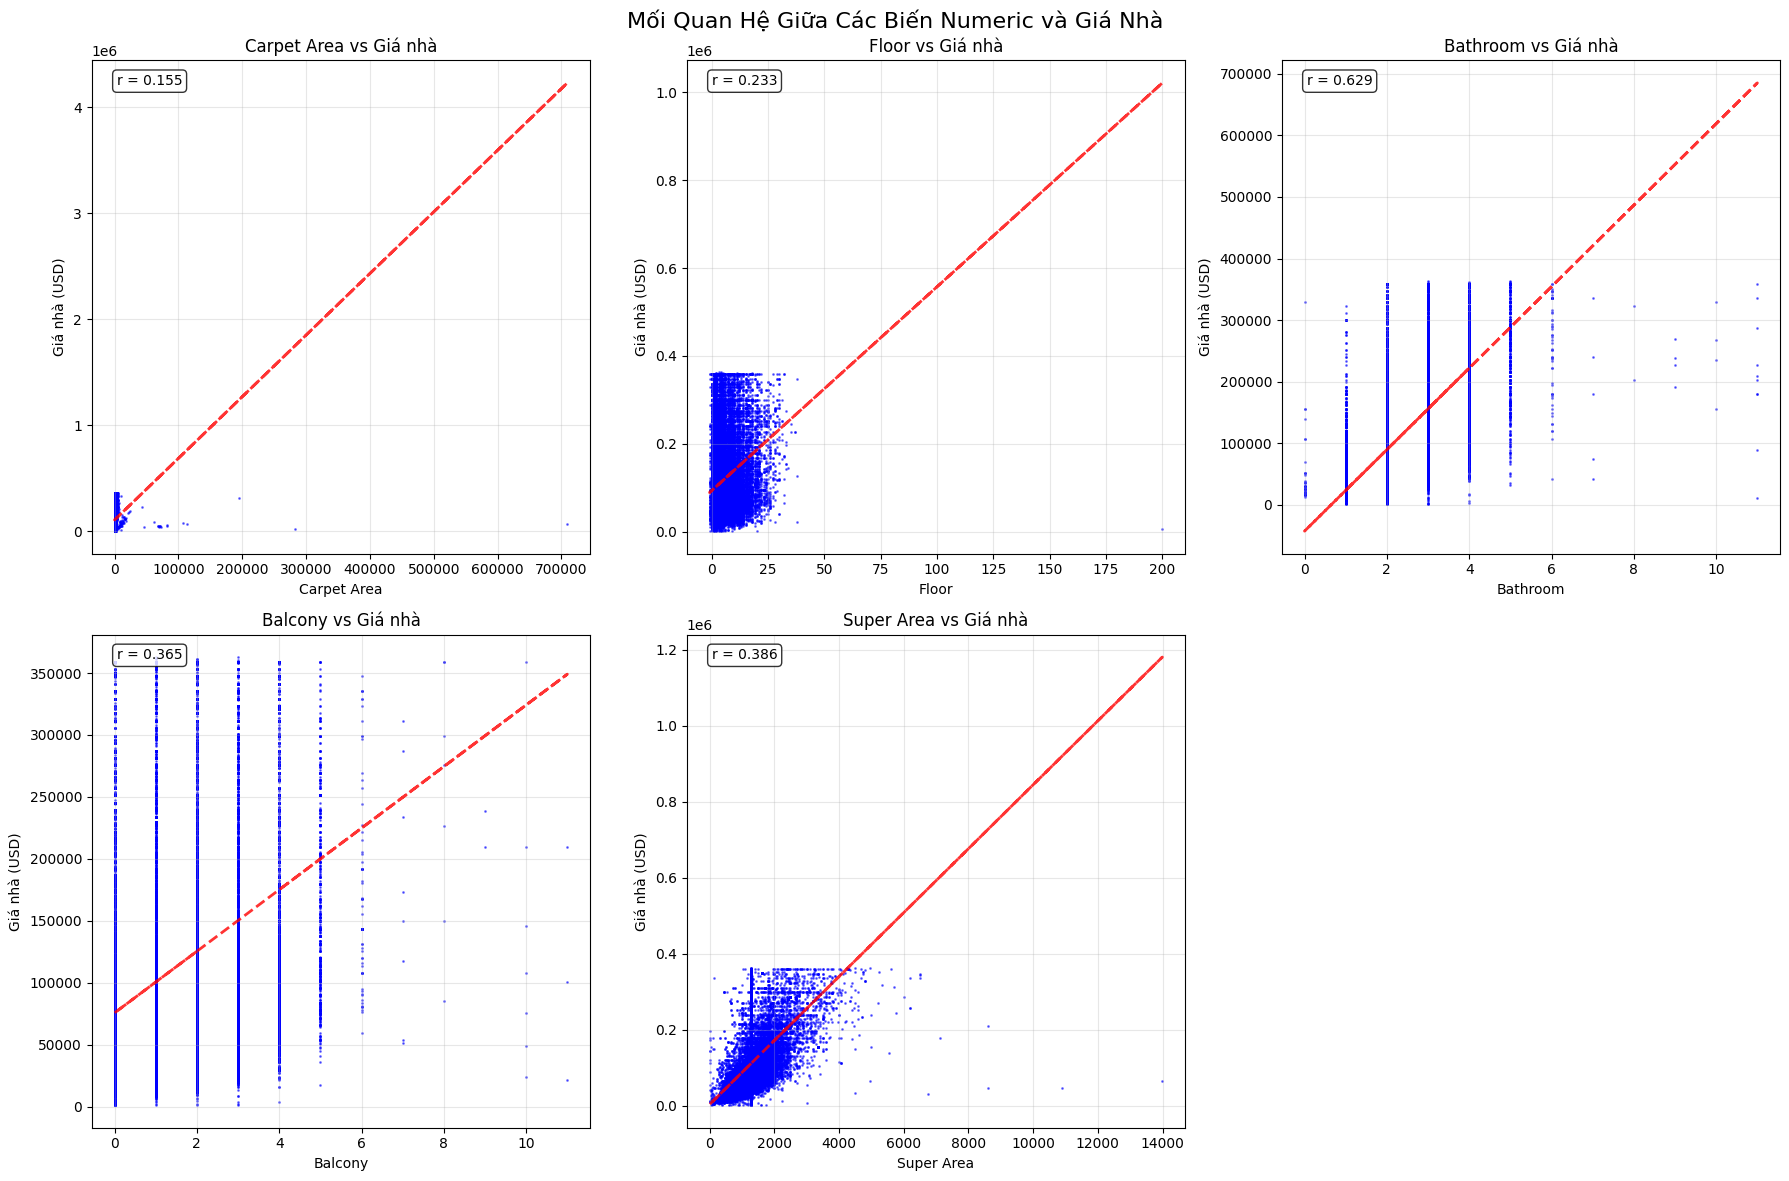

In [ ]:
# 7. Scatter Plots - Mối quan hệ với Target
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Mối Quan Hệ Giữa Các Biến Numeric và Giá Nhà', fontsize=16)

for i, col in enumerate(numeric_features):
    row = i // 3
    col_idx = i % 3
    
    # Scatter plot
    axes[row, col_idx].scatter(data[col], data[target_col], alpha=0.5, s=1, color='blue')
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel('Giá nhà (USD)')
    axes[row, col_idx].set_title(f'{col} vs Giá nhà')
    axes[row, col_idx].grid(True, alpha=0.3)
    
    # Thêm trendline
    valid_data = data[[col, target_col]].dropna()
    if len(valid_data) > 1:
        z = np.polyfit(valid_data[col], valid_data[target_col], 1)
        p = np.poly1d(z)
        axes[row, col_idx].plot(valid_data[col], p(valid_data[col]), "r--", alpha=0.8, linewidth=2)
        
        # Hiển thị correlation
        corr = valid_data[col].corr(valid_data[target_col])
        axes[row, col_idx].text(0.05, 0.95, f'r = {corr:.3f}', 
                               transform=axes[row, col_idx].transAxes, 
                               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Ẩn subplot thừa
axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# 8. Phân tích chi tiết từng biến
print("\n=== PHÂN TÍCH CHI TIẾT TỪNG BIẾN ===\n")

for col in numeric_features:
    print(f"\n--- {col.upper()} ---")
    
    # Thống kê cơ bản
    stats = data[col].describe()
    print(f"Min: {stats['min']:,.1f} | Max: {stats['max']:,.1f} | Mean: {stats['mean']:,.1f} | Median: {stats['50%']:,.1f}")
    print(f"Std: {stats['std']:,.1f} | Skewness: {data[col].skew():.2f}")
    
    # Phân tích outliers
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)][col]
    outlier_pct = len(outliers) / len(data) * 100
    print(f"Outliers: {len(outliers):,} ({outlier_pct:.1f}%) | Range: [{lower_bound:.1f}, {upper_bound:.1f}]")
    
    # Tương quan với giá
    corr = data[col].corr(data[target_col])
    print(f"Correlation với giá: {corr:.3f}")
    
    # Top/Bottom values
    if data[col].nunique() < 20:  # Nếu ít giá trị unique
        value_counts = data[col].value_counts().head(5)
        print(f"Top values: {dict(value_counts)}")
    
    print("-" * 50)


=== PHÂN TÍCH CHI TIẾT TỪNG BIẾN ===


--- CARPET AREA ---
Min: 0.8 | Max: 709,222.0 | Mean: 1,122.7 | Median: 1,008.0
Std: 2,152.6 | Skewness: 245.61
Outliers: 3,469 (2.2%) | Range: [-100.0, 2300.0]
Correlation với giá: 0.155
--------------------------------------------------

--- FLOOR ---
Min: -1.0 | Max: 200.0 | Mean: 4.2 | Median: 3.0
Std: 4.1 | Skewness: 2.59
Outliers: 10,556 (6.6%) | Range: [-5.0, 11.0]
Correlation với giá: 0.233
--------------------------------------------------

--- BATHROOM ---
Min: 0.0 | Max: 11.0 | Mean: 2.4 | Median: 2.0
Std: 0.8 | Skewness: 0.61
Outliers: 855 (0.5%) | Range: [0.5, 4.5]
Correlation với giá: 0.629
Top values: {2: np.int64(85064), 3: np.int64(48120), 1: np.int64(15214), 4: np.int64(10346), 5: np.int64(740)}
--------------------------------------------------

--- BALCONY ---
Min: 0.0 | Max: 11.0 | Mean: 1.5 | Median: 1.0
Std: 1.2 | Skewness: 0.44
Outliers: 8,935 (5.6%) | Range: [-0.5, 3.5]
Correlation với giá: 0.365
Top values: {2: np.int64(

In [70]:
# 9. Phân tích theo nhóm (Binning Analysis)
print("\n=== PHÂN TÍCH THEO NHÓM GIÁ TRỊ ===\n")

# Phân tích Bathroom (số phòng tắm)
if 'Bathroom' in data.columns:
    bathroom_analysis = data.groupby('Bathroom')[target_col].agg(['count', 'mean', 'median', 'std']).round(0)
    bathroom_analysis = bathroom_analysis[bathroom_analysis['count'] >= 50]  # Chỉ lấy nhóm có đủ dữ liệu
    print("Phân tích theo số phòng tắm:")
    print(bathroom_analysis)

# Phân tích Balcony (số ban công)
if 'Balcony' in data.columns:
    balcony_analysis = data.groupby('Balcony')[target_col].agg(['count', 'mean', 'median']).round(0)
    balcony_analysis = balcony_analysis[balcony_analysis['count'] >= 50]
    print("\nPhân tích theo số ban công:")
    print(balcony_analysis)

# Phân tích Floor (tầng) - nhóm theo khoảng
if 'Floor' in data.columns:
    data['Floor_Group'] = pd.cut(data['Floor'], bins=[0, 5, 10, 20, 50, 100], 
                                labels=['1-5', '6-10', '11-20', '21-50', '50+'])
    floor_analysis = data.groupby('Floor_Group')[target_col].agg(['count', 'mean', 'median']).round(0)
    print("\nPhân tích theo nhóm tầng:")
    print(floor_analysis)

# Phân tích diện tích theo quartiles
if 'Carpet Area' in data.columns:
    data['Area_Quartile'] = pd.qcut(data['Carpet Area'], q=4, labels=['Q1(Nhỏ)', 'Q2(TB-)', 'Q3(TB+)', 'Q4(Lớn)'])
    area_analysis = data.groupby('Area_Quartile')[target_col].agg(['count', 'mean', 'median']).round(0)
    print("\nPhân tích theo nhóm diện tích (Quartiles):")
    print(area_analysis)


=== PHÂN TÍCH THEO NHÓM GIÁ TRỊ ===

Phân tích theo số phòng tắm:
          count      mean    median      std
Bathroom                                    
1         15214   37139.0   29940.0  23819.0
2         85064   84650.0   71856.0  51273.0
3         48120  159254.0  137725.0  80953.0
4         10346  230312.0  239521.0  79290.0
5           740  277179.0  299401.0  79306.0
6            54  249057.0  258683.0  79817.0

Phân tích theo số ban công:
         count      mean    median
Balcony                           
0        39726   93084.0   76647.0
1        41812   84797.0   61078.0
2        46591  115925.0   93413.0
3        22535  153816.0  137725.0
4         8218  220019.0  229940.0
5          620  163933.0  143713.0
6           70  175690.0  143713.0

Phân tích theo nhóm tầng:
              count      mean    median
Floor_Group                            
1-5          111009  101372.0   77844.0
6-10          24729  160515.0  112575.0
11-20         12750  139528.0  116407.0
21

C:\Users\Admin\AppData\Local\Temp\ipykernel_19356\4283476555.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  floor_analysis = data.groupby('Floor_Group')[target_col].agg(['count', 'mean', 'median']).round(0)
C:\Users\Admin\AppData\Local\Temp\ipykernel_19356\4283476555.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  area_analysis = data.groupby('Area_Quartile')[target_col].agg(['count', 'mean', 'median']).round(0)


In [72]:

# ============================================================
# XỬ LÝ OUTLIERS THEO TỪNG BIẾN (Domain-based Approach)
# ============================================================

print("=" * 60)
print("XỬ LÝ OUTLIERS THEO TỪNG BIẾN")
print("=" * 60)
print(f"\nSố dòng trước khi xử lý: {len(data):,}")

# ------------------------------------------------------------
# 1. CARPET AREA — Dùng ngưỡng thực tế, không dùng IQR 1.5x
#    Căn hộ/nhà ở thực tế: max ~10,000 sqft (dinh thự lớn nhất)
#    Loại bỏ: < 1 sqft (không hợp lệ) hoặc > 10,000 sqft (bất thường)
# ------------------------------------------------------------
before = len(data)
data = data[(data['Carpet Area'] >= 1) & (data['Carpet Area'] <= 10000)]
after = len(data)
print(f"\n[Carpet Area] Loại bỏ: {before - after:,} dòng "
      f"(giữ 1–10,000 sqft) | Còn lại: {after:,}")

# ------------------------------------------------------------
# 2. FLOOR — Loại bỏ tầng > 100 (không tồn tại ở Ấn Độ)
#    Giữ lại: 0 (tầng trệt) đến 100
# ------------------------------------------------------------
before = len(data)
data = data[data['Floor'] <= 100]
after = len(data)
print(f"[Floor]       Loại bỏ: {before - after:,} dòng "
      f"(giữ ≤ 100 tầng) | Còn lại: {after:,}")

# ------------------------------------------------------------
# 3. BATHROOM — GIỮ NGUYÊN
#    Tương quan cao với giá (0.629), nhà hạng sang có 5–11 phòng tắm
#    Chỉ loại giá trị 0 (không hợp lệ — mọi nhà đều có ≥ 1 phòng tắm)
# ------------------------------------------------------------
before = len(data)
data = data[data['Bathroom'] >= 1]
after = len(data)
print(f"[Bathroom]    Loại bỏ: {before - after:,} dòng "
      f"(loại = 0, giữ ≥ 1) | Còn lại: {after:,}")

# ------------------------------------------------------------
# 4. BALCONY — Kiểm tra logic domain
#    Ban công > 10 là bất thường; giá trị âm không hợp lệ
# ------------------------------------------------------------
before = len(data)
data = data[(data['Balcony'] >= 0) & (data['Balcony'] <= 10)]
after = len(data)
print(f"[Balcony]     Loại bỏ: {before - after:,} dòng "
      f"(giữ 0–10) | Còn lại: {after:,}")

# ------------------------------------------------------------
# 5. SUPER AREA — KHÔNG XỬ LÝ BẰNG IQR
#    IQR = 0 (Q1 = Q3 = 1285), áp dụng IQR sẽ loại ~43% dữ liệu
#    Chỉ loại các giá trị âm hoặc bằng 0 (không hợp lệ về vật lý)
# ------------------------------------------------------------
before = len(data)
data = data[data['Super Area'] > 0]
after = len(data)
print(f"[Super Area]  Loại bỏ: {before - after:,} dòng "
      f"(loại ≤ 0) | Còn lại: {after:,}")

# ------------------------------------------------------------
# Tổng kết
# ------------------------------------------------------------
print(f"\n{'=' * 60}")
print(f"Tổng số dòng sau xử lý outliers: {len(data):,}")
print(f"{'=' * 60}")


XỬ LÝ OUTLIERS THEO TỪNG BIẾN

Số dòng trước khi xử lý: 159,599

[Carpet Area] Loại bỏ: 50 dòng (giữ 1–10,000 sqft) | Còn lại: 159,549
[Floor]       Loại bỏ: 1 dòng (giữ ≤ 100 tầng) | Còn lại: 159,548
[Bathroom]    Loại bỏ: 36 dòng (loại = 0, giữ ≥ 1) | Còn lại: 159,512
[Balcony]     Loại bỏ: 3 dòng (giữ 0–10) | Còn lại: 159,509
[Super Area]  Loại bỏ: 0 dòng (loại ≤ 0) | Còn lại: 159,509

Tổng số dòng sau xử lý outliers: 159,509


In [82]:
# ============================================================
# XÂY DỰNG MÔ HÌNH DỰ ĐOÁN GIÁ (RIDGE REGRESSION & OUTLIER HANDLING)
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# 1. Lọc bỏ các dòng có giá trị mục tiêu bằng 0 hoặc NaN
data_model = data.copy()
data_model = data_model.dropna(subset=[target_col])
data_model = data_model[data_model[target_col] > 0]

# 2. Xử lý missing values bằng median cho features
all_features = data_model.drop(columns=[target_col]).select_dtypes(include=[np.number]).columns
for col in all_features:
    if data_model[col].isnull().sum() > 0:
        data_model[col] = data_model[col].fillna(data_model[col].median())

# 3. LỌC OUTLIERS (Ngoại lai) TRÊN TẬP DỮ LIỆU ĐỂ TRÁNH NHIỄU MÔ HÌNH
Q1 = data_model[target_col].quantile(0.01) # Loại bỏ 1% nhà quá rẻ
Q3 = data_model[target_col].quantile(0.99) # Loại bỏ 1% siêu biệt thự (outliers)
data_model = data_model[(data_model[target_col] >= Q1) & (data_model[target_col] <= Q3)]

# 4. Chọn đặc trưng và mục tiêu (Log transform cho biến mục tiêu)
X = data_model[all_features]
y = np.log(data_model[target_col]) # Log transform tự nhiên

# 5. Chia tập train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Kích thước tập huấn luyện (Train): {X_train.shape[0]} mẫu")
print(f"Kích thước tập kiểm tra (Test): {X_test.shape[0]} mẫu\n")

# 6. Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Khởi tạo và huấn luyện mô hình Ridge với lực phạt RẤT LỚN
model_ridge = Ridge(alpha=100.0) # Tăng lực phạt alpha lên 100
model_ridge.fit(X_train_scaled, y_train)

# 8. Dự đoán và đảo ngược Log
y_pred_log = model_ridge.predict(X_test_scaled)
y_pred = np.exp(y_pred_log)
y_test_real = np.exp(y_test)

# 9. Đánh giá mô hình
mse = mean_squared_error(y_test_real, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_real, y_pred)
r2 = r2_score(y_test_real, y_pred)

print("=== KẾT QUẢ RIDGE REGRESSION SAU KHI LỌC OUTLIERS & TĂNG ALPHA ===")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"R-squared (R2) TÍNH TRÊN GIÁ GỐC: {r2:.4f}")

# Tính R2 trên khoảng giá Log (đây là cách đánh giá chuẩn cho mô hình dùng Log-transform)
r2_log = r2_score(y_test, y_pred_log)
print(f"R-squared (R2) TÍNH TRÊN KHÔNG GIAN LOG: {r2_log:.4f}")

# 10. Top 5 biến ảnh hưởng mạnh nhất
coeff_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model_ridge.coef_})
coeff_df['Abs_Coef'] = coeff_df['Coefficient'].abs()
print("\n=== TOP 5 ĐẶC TRƯNG ẢNH HƯỞNG MẠNH NHẤT ===")
print(coeff_df.sort_values(by='Abs_Coef', ascending=False)[['Feature', 'Coefficient']].head(10))

# So sánh thực tế vs dự đoán
comparison = pd.DataFrame({'Thực tế': y_test_real, 'Dự đoán': y_pred})
print("\n=== MỘT SỐ DỰ ĐOÁN THỰC TẾ ===")
print(comparison.head(5))

Kích thước tập huấn luyện (Train): 126271 mẫu
Kích thước tập kiểm tra (Test): 31568 mẫu

=== KẾT QUẢ RIDGE REGRESSION SAU KHI LỌC OUTLIERS & TĂNG ALPHA ===
Mean Squared Error (MSE): 50,991,226,132.79
Root Mean Squared Error (RMSE): 225,812.37
Mean Absolute Error (MAE): 34,843.45
R-squared (R2) TÍNH TRÊN GIÁ GỐC: -7.0778
R-squared (R2) TÍNH TRÊN KHÔNG GIAN LOG: 0.7080

=== TOP 5 ĐẶC TRƯNG ẢNH HƯỞNG MẠNH NHẤT ===
          Feature  Coefficient
0     Carpet Area     0.354742
2        Bathroom     0.141704
67  loc_new-delhi     0.121727
62     loc_mumbai     0.083868
52     loc_jaipur    -0.083021
45    loc_gurgaon     0.063250
32    loc_bhiwadi    -0.062162
3         Balcony     0.059309
84   loc_vadodara    -0.057243
40  loc_faridabad    -0.056634

=== MỘT SỐ DỰ ĐOÁN THỰC TẾ ===
              Thực tế       Dự đoán
142381   59880.239521  46377.344958
32263    41916.167665  63058.649169
69991    65868.263473  80520.557631
98968    53892.215569  53439.754401
105842  143712.574850  86239.412